# Noise-filtered linearizer: $L^1$-ball optimization

This version minimizes symbolic coordinate partials or directional derivatives over

$$
\lVert x-x_0\rVert_1 = \sum_i |x_i-x_{0,i}| \le r.
$$

The domain is intersected with the nonnegative orthant by default. Winner-quota constraints are **disabled by default**, so paths may leave the regular $T_j\ge q$ region.

In [1]:
import sys
from pathlib import Path

import numpy as np
import sympy as sp

# Keep this notebook and noise_filtered_linearizer.py in the same directory.
sys.path.insert(0, str(Path.cwd()))

from noise_filtered_linearizer import (
    L1BallMinimum,
    build_recursive_margin,
    directional_derivative,
    make_symbolic_array,
    margin_partial,
    minimize_coordinate_partial,
    minimize_directional_derivative,
    minimize_expression_over_l1_ball,
)

sp.init_printing()
q = sp.Symbol("q", positive=True)

## Construct the degree-1 symbolic model

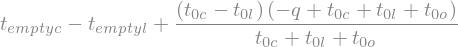

In [2]:
t1 = make_symbolic_array(1)
model1 = build_recursive_margin(t1, q)
model1.margin

In [4]:
expression = margin_partial(model1, (1,0))

∂M_cl/∂t_0_c =
   t_0_c - t₀ ₗ       (t_0_c - t₀ ₗ)⋅(-q + t_0_c + t₀ ₗ + t₀ ₒ)   -q + t_0_c + ↪
─────────────────── - ───────────────────────────────────────── + ──────────── ↪
t_0_c + t₀ ₗ + t₀ ₒ                                 2               t_0_c + t₀ ↪
                               (t_0_c + t₀ ₗ + t₀ ₒ)                           ↪

↪  t₀ ₗ + t₀ ₒ
↪ ────────────
↪  ₗ + t₀ ₒ   
↪             


In [6]:
active_variables = tuple(
    variable
    for variable in model1.variables
    if variable in expression.free_symbols
)

hessian = sp.hessian(expression, active_variables)

base1 = np.array([
    [80.0, 50.0, 7.0],
    [ 30.0,  30.0, 100.0],
])

numeric_hessian = sp.lambdify(
    active_variables,
    hessian.subs(base1),
    modules="numpy",
    cse=True,
)

ValueError: too many values to unpack (expected 2)

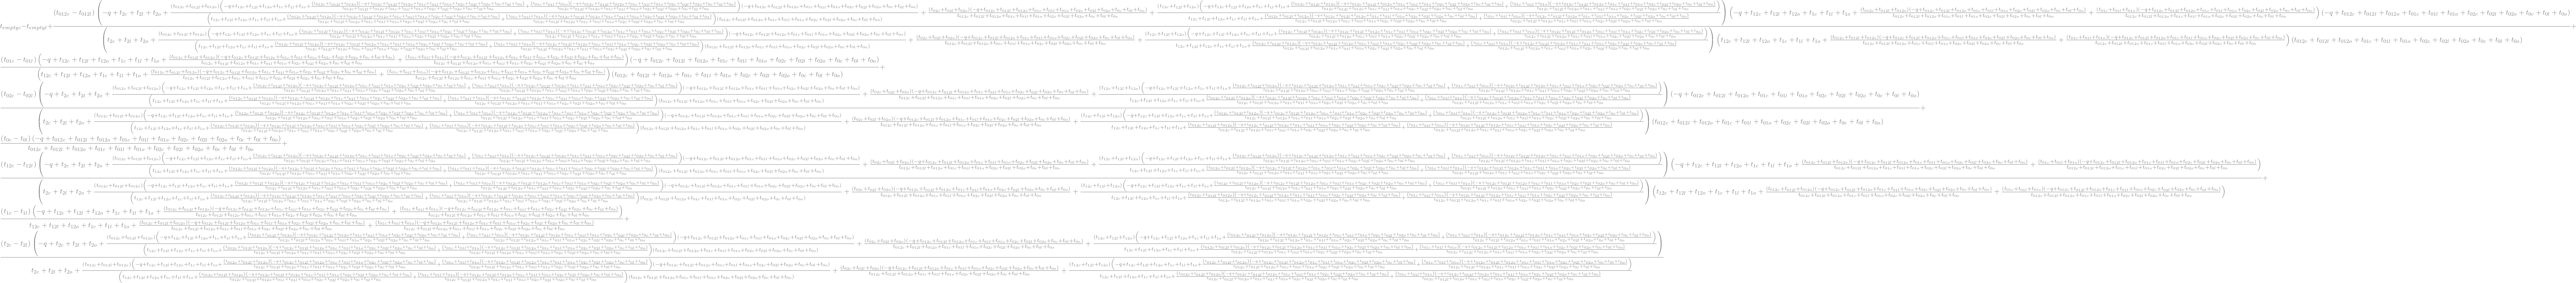

In [7]:
t3 = make_symbolic_array(3)
model3 = build_recursive_margin(t3, q)
model3.margin

## Minimize a coordinate partial over a diamond

In [ ]:
base1 = np.array([
    [80.0, 50.0, 7.0],
    [ 30.0,  30.0, 100.0],
])

result = minimize_coordinate_partial(
    model1,
    base_point=base1,
    radius=50.0,
    coordinate=(1, 0),
    parameter_values={q: 100.0},
    # require_winner_quota=False is now the default.
    seed=7,
    restarts=3,
    maxiter=250,
    popsize=12,
    tol=1e-7,
)

print("candidate minimum:", result.minimum)
print("L1 distance:", result.l1_distance)
print("feasible:", result.feasible)
print("restart minima:", result.restart_minima)
print("solver success:", result.optimizer_result.success)
print("solver message:", result.optimizer_result.message)
result.point

candidate minimum: -0.15702479247700737
L1 distance: 49.99999998808717
feasible: True
restart minima: (-0.15702479133423497, -0.15702479247700737, -0.1570247920813148)
solver success: True
solver message: Optimization terminated successfully.


array([[8.00000000e+01, 5.00000000e+01, 7.00000000e+00],
       [4.92786825e-08, 3.00000000e+01, 8.00000000e+01]])

The reported point must satisfy

$$
\sum_i |x_i-x_{0,i}|\le 2.
$$

In [4]:
np.sum(np.abs(result.point - base1))

## Minimize a full ballot-discrepancy direction

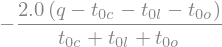

In [13]:
theta = np.zeros(model1.symbols.shape, dtype=float)
theta[1, 1] = -1.0
theta[1, 0] = 1.0

derivative = directional_derivative(model1, theta, simplify=True)
derivative

In [14]:
direction_result = minimize_directional_derivative(
    model1,
    base_point=base1,
    radius=30.0,
    direction=theta,
    parameter_values={q: 100.0},
    seed=11,
    restarts=3,
    maxiter=250,
    popsize=12,
    tol=1e-7,
)

print("candidate minimum:", direction_result.minimum)
print("L1 distance:", direction_result.l1_distance)
print("restart minima:", direction_result.restart_minima)
direction_result.point

/home/nardo/research/meek/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


candidate minimum: 0.46153846153846156
L1 distance: 29.999999999999993
restart minima: (0.46153846153846156, 0.46153846153846156, 0.46153846153846156)


array([[80.        , 50.        ,  7.        ],
       [ 4.07801224, 28.39916305, 97.52282471]])

## Sanity check with a problem whose exact answer is known

In [7]:
t0 = make_symbolic_array(0)
model0 = build_recursive_margin(t0, q)
x, y, z = model0.variables
center = np.array([[2.0, 2.0, 2.0]])

# Over ||point-center||_1 <= 1, min(x+y) = 4-1 = 3.
check = minimize_expression_over_l1_ball(
    model0,
    x + y,
    center,
    radius=10,
    seed=3,
    restarts=2,
    maxiter=150,
    popsize=10,
)

print("computed:", check.minimum)
print("expected: 3.0")
print("point:", check.point)
print("L1 distance:", check.l1_distance)

computed: 0.0
expected: 3.0
point: [[0. 0. 2.]]
L1 distance: 4.0


## Interpreting the result

`feasible=True` verifies the returned point against the $L^1$ radius, nonnegativity, and any optional quota constraints. `optimizer_result.success=True` only means SciPy met its numerical stopping/feasibility criteria. Neither flag certifies that no lower point exists.

`restart_minima` is useful diagnostically. Agreement across independent restarts increases empirical confidence, but it is not an error bound.

round 0: theta=0, noise filtered capital=1.050531914893617, conservative capital=1.050531914893617
round 1: theta=0, noise filtered capital=1.1036173042100497, conservative capital=1.1036173042100497
round 2: theta=0, noise filtered capital=1.1593851999015148, conservative capital=1.1593851999015148
round 3: theta=1, noise filtered capital=0.6843702828397378, conservative capital=0.05796925999507579
round 4: theta=0, noise filtered capital=0.718952823727916, conservative capital=0.060898557707592914
round 5: theta=0, noise filtered capital=0.7552828866290607, conservative capital=0.06397587844281702
round 6: theta=0, noise filtered capital=0.7934487771768057, conservative capital=0.06720870208753384
round 7: theta=0, noise filtered capital=0.8335432632575486, conservative capital=0.07060488650153156
round 8: theta=0, noise filtered capital=0.8756638004966267, conservative capital=0.07417268661730043
round 9: theta=0, noise filtered capital=0.9199127691387434, conservative capital=0.077

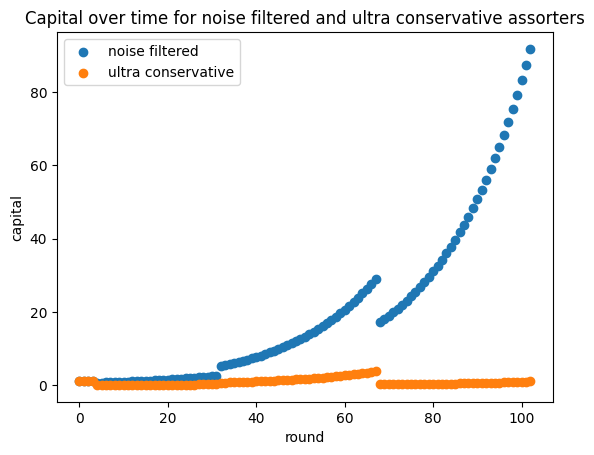

In [20]:
import random

theta_space = [0]*277 + [-1]*10 + [1]*10
noise_filtered_assorter = {
    0: 0,
    -1: -.95,
    1:0.46
}
ultra_conservative_assorter = {
    0:0,
    -1: -2,
    1: 1
}

random.shuffle(theta_space)

recorded_margin = 30
N = 297
v= recorded_margin / N

def w_out(assorted_value, _v = v):
    return (1-assorted_value) / (2-_v)

noise_filtered_capital = 1
conservative_capital = 1

noise_filtered_record = []
conservative_record = []

lambda_value = 1.9

for i in range(N):
    noise_filtered_record.append(noise_filtered_capital)
    conservative_record.append(conservative_capital)
    theta = random.choice(theta_space)
    noise_filtered_capital *= (1+ lambda_value * (w_out(noise_filtered_assorter[theta]) - 1/2))
    conservative_capital *= (1+ lambda_value * (w_out(ultra_conservative_assorter[theta]) - 1/2))
    print(f"round {i}: theta={theta}, noise filtered capital={noise_filtered_capital}, conservative capital={conservative_capital}")

print("final noise filtered capital:", noise_filtered_capital)
print("final conservative capital:", conservative_capital)

# make a scatter plot with both records on the same axis
# truncate both records when the noise-filtered capital exceeds 100

import matplotlib.pyplot as plt

truncate_index = next(i for i, capital in enumerate(noise_filtered_record) if capital > 100)
plt.scatter(range(truncate_index), noise_filtered_record[:truncate_index], label="noise filtered")
plt.scatter(range(truncate_index), conservative_record[:truncate_index], label="ultra conservative")
#plt.yscale("log")
plt.xlabel("round")
plt.ylabel("capital")
plt.legend()
plt.title("Capital over time for noise filtered and ultra conservative assorters")
plt.show()

In [8]:
from dataclasses import dataclass
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

import noise_filtered_linearizer as nfl


q = sp.Symbol("q", positive=True)
Q = 100.0
PARAMS = {q: Q}

models = {}

for degree in (1, 2):
    totals = nfl.make_symbolic_array(degree)
    models[degree] = nfl.build_recursive_margin(totals, q)


def compile_tallies(model, parameter_values=PARAMS):
    expressions = [
        tally.subs(parameter_values)
        for tally in model.winner_tallies
    ]

    return sp.lambdify(
        model.variables,
        expressions,
        modules="numpy",
        cse=True,
    )


def evaluate_tallies(model, point, parameter_values=PARAMS):
    if model.degree == 0:
        return np.empty(0)

    tally_fn = compile_tallies(model, parameter_values)

    return np.asarray(
        tally_fn(*np.asarray(point, dtype=float).reshape(-1)),
        dtype=float,
    ).reshape(-1)


def sample_regular_points(
    model,
    *,
    n_points,
    quota_value=Q,
    parameter_values=PARAMS,
    mean_per_cell=None,
    min_quota_slack=0.0,
    seed=0,
    batch_size=512,
    max_batches=1000,
):
    """
    Sample nonnegative ballot-total arrays and retain points satisfying

        T_j >= quota_value + min_quota_slack

    for every winner j.
    """
    rng = np.random.default_rng(seed)
    tally_fn = compile_tallies(model, parameter_values)

    if mean_per_cell is None:
        mean_per_cell = quota_value / 2

    accepted = []

    for _ in range(max_batches):
        # Positive samples with substantial variation between coordinates.
        batch = rng.gamma(
            shape=2.0,
            scale=mean_per_cell / 2.0,
            size=(batch_size, *model.symbols.shape),
        )

        for point in batch:
            tallies = np.asarray(
                tally_fn(*point.reshape(-1)),
                dtype=float,
            ).reshape(-1)

            regular = (
                np.all(np.isfinite(tallies))
                and np.all(
                    tallies >= quota_value + min_quota_slack
                )
            )

            if regular:
                accepted.append(point)

                if len(accepted) == n_points:
                    return np.stack(accepted)

    raise RuntimeError(
        "Could not sample enough regular-domain points. "
        "Increase mean_per_cell or reduce min_quota_slack."
    )

In [9]:
def compile_hessian(
    model,
    expression,
    parameter_values=PARAMS,
):
    expression = sp.sympify(expression).subs(parameter_values)

    extra_symbols = expression.free_symbols.difference(
        model.variables
    )

    if extra_symbols:
        raise ValueError(
            "Unsubstituted symbols: "
            f"{sorted(map(str, extra_symbols))}"
        )

    symbolic_hessian = sp.hessian(
        expression,
        model.variables,
    )

    numeric_hessian = sp.lambdify(
        model.variables,
        symbolic_hessian,
        modules="numpy",
        cse=True,
    )

    return symbolic_hessian, numeric_hessian


def hessian_sample_table(
    model,
    expression,
    points,
    *,
    parameter_values=PARAMS,
    radius_for_scale=None,
    eigenvalue_tolerance=1e-10,
):
    """
    Evaluate the Hessian eigenvalues at each supplied point.

    negative_quadratic_scale is

        0.5 * max(0, -lambda_min) * radius**2.

    Since ||delta||_2 <= ||delta||_1 <= radius, this gives a local
    scale for the possible second-order benefit from negative curvature.
    It is not a bound over the whole ball unless the Hessian is controlled
    throughout that ball.
    """
    _, hessian_fn = compile_hessian(
        model,
        expression,
        parameter_values,
    )

    rows = []

    for sample_number, point in enumerate(points):
        H = np.asarray(
            hessian_fn(
                *np.asarray(point, dtype=float).reshape(-1)
            ),
            dtype=float,
        )

        # Remove insignificant floating-point asymmetry.
        H = 0.5 * (H + H.T)

        eigenvalues = np.linalg.eigvalsh(H)

        row = {
            "sample": sample_number,
            "lambda_min": eigenvalues[0],
            "lambda_max": eigenvalues[-1],
            "spectral_norm": np.max(
                np.abs(eigenvalues)
            ),
            "negative_eigenvalues": np.count_nonzero(
                eigenvalues < -eigenvalue_tolerance
            ),
            "near_zero_eigenvalues": np.count_nonzero(
                np.abs(eigenvalues)
                <= eigenvalue_tolerance
            ),
        }

        if radius_for_scale is not None:
            row["negative_quadratic_scale"] = (
                0.5
                * max(0.0, -eigenvalues[0])
                * radius_for_scale**2
            )

        rows.append(row)

    return pd.DataFrame(rows)


Degree 1: Hessian of M


,lambda_min,lambda_max,spectral_norm,negative_eigenvalues,near_zero_eigenvalues,negative_quadratic_scale
count,250.000000,250.000000,250.000000,250.0,250.0,250.000000
mean,-0.011032,0.012125,0.015070,1.0,4.0,0.551595
std,0.006684,0.008130,0.008150,0.0,0.0,0.334215
min,-0.035853,0.000916,0.002207,1.0,4.0,0.064018
5%,-0.024642,0.002864,0.004775,1.0,4.0,0.140159
25%,-0.014347,0.005883,0.007876,1.0,4.0,0.308176
50%,-0.009700,0.009935,0.013980,1.0,4.0,0.485011
75%,-0.006164,0.017303,0.020124,1.0,4.0,0.717353
95%,-0.002803,0.028433,0.029546,1.0,4.0,1.232079
max,-0.001280,0.041457,0.041457,1.0,4.0,1.792663


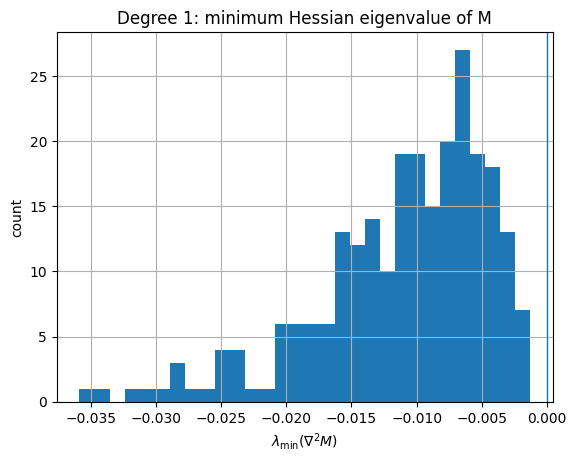


Degree 2: Hessian of M


,lambda_min,lambda_max,spectral_norm,negative_eigenvalues,near_zero_eigenvalues,negative_quadratic_scale
count,250.000000,250.000000,250.000000,250.0,250.0,250.000000
mean,-0.010101,0.010213,0.012163,2.0,8.0,0.505059
std,0.006257,0.006184,0.007046,0.0,0.0,0.312840
min,-0.046390,0.002514,0.003327,2.0,8.0,0.137742
5%,-0.019734,0.003635,0.004745,2.0,8.0,0.175393
25%,-0.012560,0.006210,0.007374,2.0,8.0,0.290258
50%,-0.008562,0.008740,0.010540,2.0,8.0,0.428118
75%,-0.005805,0.012069,0.014853,2.0,8.0,0.628015
95%,-0.003508,0.024583,0.026045,2.0,8.0,0.986717
max,-0.002755,0.041569,0.046390,2.0,8.0,2.319479


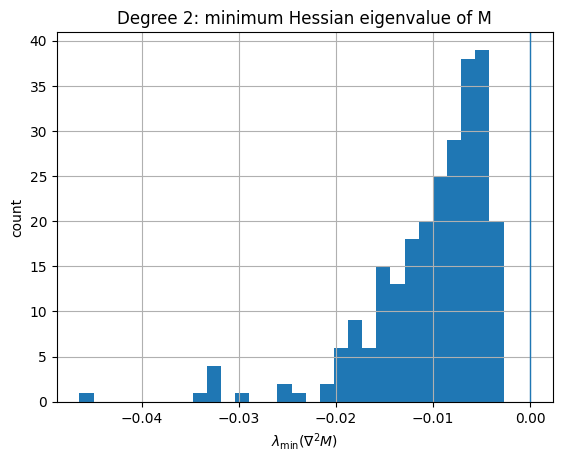

In [10]:
RADIUS = 10.0

margin_curvature = {}

for degree, model in models.items():
    points = sample_regular_points(
        model,
        n_points=250,
        quota_value=Q,
        mean_per_cell=Q / 2,
        seed=100 + degree,
    )

    table = hessian_sample_table(
        model,
        model.margin,
        points,
        radius_for_scale=RADIUS,
    )

    margin_curvature[degree] = table

    print(f"\nDegree {degree}: Hessian of M")

    display(
        table[
            [
                "lambda_min",
                "lambda_max",
                "spectral_norm",
                "negative_eigenvalues",
                "near_zero_eigenvalues",
                "negative_quadratic_scale",
            ]
        ].describe(
            percentiles=[
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
            ]
        )
    )

    plt.figure()
    table["lambda_min"].hist(bins=30)
    plt.axvline(0.0, linewidth=1)
    plt.title(
        f"Degree {degree}: minimum Hessian eigenvalue of M"
    )
    plt.xlabel(r"$\lambda_{\min}(\nabla^2 M)$")
    plt.ylabel("count")
    plt.show()


Degree 1: Hessian of directional derivative


,lambda_min,lambda_max,spectral_norm,negative_eigenvalues,near_zero_eigenvalues,negative_quadratic_scale
count,250.000000,2.500000e+02,250.000000,250.0,250.0,250.000000
mean,-0.000422,3.693326e-20,0.000422,1.0,5.0,0.021082
std,0.000304,4.742816e-20,0.000304,0.0,0.0,0.015198
min,-0.001176,0.000000e+00,0.000024,1.0,5.0,0.001194
5%,-0.001050,0.000000e+00,0.000065,1.0,5.0,0.003269
25%,-0.000610,5.800546e-21,0.000184,1.0,5.0,0.009206
50%,-0.000324,2.261606e-20,0.000324,1.0,5.0,0.016189
75%,-0.000184,4.929622e-20,0.000610,1.0,5.0,0.030484
95%,-0.000065,1.276640e-19,0.001050,1.0,5.0,0.052523
max,-0.000024,2.507812e-19,0.001176,1.0,5.0,0.058824


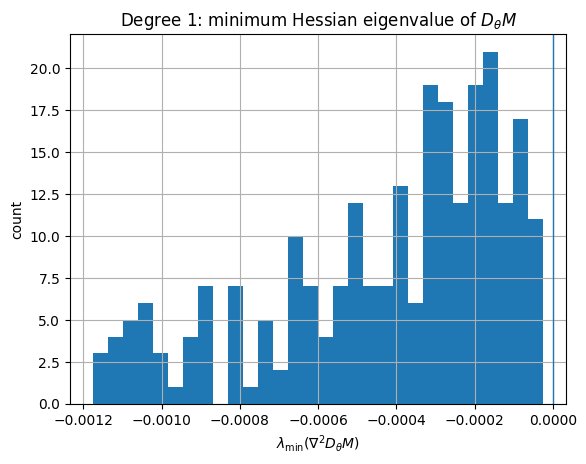


Degree 2: Hessian of directional derivative


,lambda_min,lambda_max,spectral_norm,negative_eigenvalues,near_zero_eigenvalues,negative_quadratic_scale
count,250.000000,2.500000e+02,250.000000,250.0,250.0,250.000000
mean,-0.000138,9.474699e-06,0.000140,2.0,9.0,0.006885
std,0.000107,5.352159e-05,0.000112,0.0,0.0,0.005351
min,-0.000914,2.366480e-08,0.000028,2.0,9.0,0.001399
5%,-0.000339,8.261902e-08,0.000041,2.0,9.0,0.002054
25%,-0.000162,3.680506e-07,0.000074,2.0,9.0,0.003721
50%,-0.000108,1.207122e-06,0.000108,2.0,9.0,0.005395
75%,-0.000074,3.068881e-06,0.000162,2.0,9.0,0.008106
95%,-0.000041,1.930273e-05,0.000357,2.0,9.0,0.016952
max,-0.000028,5.493564e-04,0.000914,2.0,9.0,0.045710


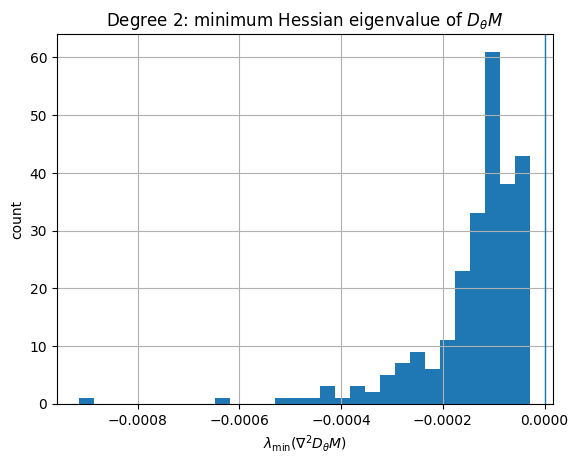

In [11]:
directional_curvature = {}

for degree, model in models.items():
    theta = np.zeros(
        model.symbols.shape,
        dtype=float,
    )

    # Final row:
    #   c increases by 1
    #   l decreases by 1
    # Therefore theta_c + theta_l + theta_o = 0.
    theta[-1, 0] = 1.0
    theta[-1, 1] = -1.0

    objective = nfl.directional_derivative(
        model,
        theta,
        simplify=True,
    )

    points = sample_regular_points(
        model,
        n_points=250,
        quota_value=Q,
        mean_per_cell=Q / 2,
        seed=200 + degree,
    )

    table = hessian_sample_table(
        model,
        objective,
        points,
        radius_for_scale=RADIUS,
    )

    directional_curvature[degree] = (
        objective,
        table,
    )

    print(
        f"\nDegree {degree}: "
        "Hessian of directional derivative"
    )

    display(
        table[
            [
                "lambda_min",
                "lambda_max",
                "spectral_norm",
                "negative_eigenvalues",
                "near_zero_eigenvalues",
                "negative_quadratic_scale",
            ]
        ].describe(
            percentiles=[
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
            ]
        )
    )

    plt.figure()
    table["lambda_min"].hist(bins=30)
    plt.axvline(0.0, linewidth=1)
    plt.title(
        f"Degree {degree}: "
        r"minimum Hessian eigenvalue of $D_\theta M$"
    )
    plt.xlabel(
        r"$\lambda_{\min}(\nabla^2 D_\theta M)$"
    )
    plt.ylabel("count")
    plt.show()

In [12]:
@dataclass(frozen=True)
class ProjectedGradientMinimum:
    minimum: float
    point: np.ndarray
    l1_distance: float
    projected_gradient_norm: float
    converged: bool
    iterations: int
    start_minima: tuple[float, ...]


def project_nonnegative_l1_ball(
    y,
    center,
    radius,
    *,
    tolerance=1e-12,
):
    """
    Euclidean projection onto

        {x >= 0, ||x - center||_1 <= radius}.

    The implementation uses soft thresholding around center and
    bisection on the Lagrange multiplier.
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    center = np.asarray(
        center,
        dtype=float,
    ).reshape(-1)

    if y.shape != center.shape:
        raise ValueError(
            "y and center must have the same shape"
        )

    if np.any(center < -tolerance):
        raise ValueError(
            "This helper assumes a nonnegative center"
        )

    if radius < 0:
        raise ValueError(
            "radius must be nonnegative"
        )

    clipped = np.maximum(y, 0.0)

    if (
        np.sum(np.abs(clipped - center))
        <= radius + tolerance
    ):
        return clipped

    displacement_from_center = y - center

    def point_for_multiplier(lam):
        displacement = (
            np.sign(displacement_from_center)
            * np.maximum(
                np.abs(displacement_from_center) - lam,
                0.0,
            )
        )

        # x >= 0 is equivalent to displacement >= -center.
        displacement = np.maximum(
            displacement,
            -center,
        )

        return center + displacement

    lower = 0.0
    upper = max(
        1.0,
        float(
            np.max(
                np.abs(displacement_from_center)
            )
        ),
    )

    while (
        np.sum(
            np.abs(
                point_for_multiplier(upper)
                - center
            )
        )
        > radius
    ):
        upper *= 2.0

    for _ in range(80):
        midpoint = 0.5 * (lower + upper)
        candidate = point_for_multiplier(midpoint)

        if (
            np.sum(np.abs(candidate - center))
            > radius
        ):
            lower = midpoint
        else:
            upper = midpoint

    return point_for_multiplier(upper)


def compile_objective_and_gradient(
    model,
    expression,
    parameter_values=PARAMS,
):
    expression = sp.sympify(expression).subs(
        parameter_values
    )

    extra_symbols = expression.free_symbols.difference(
        model.variables
    )

    if extra_symbols:
        raise ValueError(
            "Unsubstituted symbols: "
            f"{sorted(map(str, extra_symbols))}"
        )

    gradient_expression = [
        sp.diff(expression, variable)
        for variable in model.variables
    ]

    objective_raw = sp.lambdify(
        model.variables,
        expression,
        modules="numpy",
        cse=True,
    )

    gradient_raw = sp.lambdify(
        model.variables,
        gradient_expression,
        modules="numpy",
        cse=True,
    )

    def objective(x):
        try:
            value = float(
                np.asarray(
                    objective_raw(
                        *np.asarray(
                            x,
                            dtype=float,
                        ).reshape(-1)
                    )
                )
            )
        except Exception:
            return np.inf

        return value if np.isfinite(value) else np.inf

    def gradient(x):
        try:
            value = np.asarray(
                gradient_raw(
                    *np.asarray(
                        x,
                        dtype=float,
                    ).reshape(-1)
                ),
                dtype=float,
            ).reshape(-1)
        except Exception:
            return np.full(
                np.asarray(x).size,
                np.nan,
            )

        return value

    return objective, gradient


def random_l1_start(
    center,
    radius,
    rng,
):
    """
    Generate a dispersed point in the L1 ball, then enforce
    nonnegativity through the exact projection.
    """
    center = np.asarray(
        center,
        dtype=float,
    ).reshape(-1)

    dimension = center.size

    weights = rng.dirichlet(
        np.ones(dimension)
    )

    signs = rng.choice(
        (-1.0, 1.0),
        size=dimension,
    )

    radial_fraction = (
        rng.random() ** (1.0 / dimension)
    )

    trial = (
        center
        + radius
        * radial_fraction
        * signs
        * weights
    )

    return project_nonnegative_l1_ball(
        trial,
        center,
        radius,
    )


def minimize_expression_projected_gradient(
    model,
    expression,
    base_point,
    radius,
    *,
    parameter_values=PARAMS,
    n_starts=25,
    seed=0,
    maxiter=2000,
    initial_step=1.0,
    maximum_step=100.0,
    backtrack_factor=0.5,
    armijo_constant=1e-4,
    projected_gradient_tolerance=1e-8,
    step_tolerance=1e-12,
):
    """
    Multi-start projected gradient descent over the same nonnegative
    L1 ball used by minimize_expression_over_l1_ball.

    No T_j >= q constraints are imposed.
    """
    center = np.asarray(
        base_point,
        dtype=float,
    )

    center_flat = center.reshape(-1)

    if np.any(center_flat < 0):
        raise ValueError(
            "This helper assumes base_point >= 0"
        )

    objective, gradient = (
        compile_objective_and_gradient(
            model,
            expression,
            parameter_values,
        )
    )

    rng = np.random.default_rng(seed)

    starts = [center_flat.copy()]

    # Axis tips are useful because a nearly linear objective often
    # attains its minimum on a tip or low-dimensional face.
    for coordinate in range(center_flat.size):
        if len(starts) >= n_starts:
            break

        for sign in (-1.0, 1.0):
            trial = center_flat.copy()
            trial[coordinate] += sign * radius

            starts.append(
                project_nonnegative_l1_ball(
                    trial,
                    center_flat,
                    radius,
                )
            )

            if len(starts) >= n_starts:
                break

    while len(starts) < n_starts:
        starts.append(
            random_l1_start(
                center_flat,
                radius,
                rng,
            )
        )

    runs = []

    for start in starts:
        x = start.copy()
        fx = objective(x)
        step = initial_step
        converged = False
        iteration = 0

        for iteration in range(1, maxiter + 1):
            gx = gradient(x)

            if (
                not np.isfinite(fx)
                or not np.all(np.isfinite(gx))
            ):
                break

            # With a unit step, this is the projected-gradient
            # stationarity mapping.
            unit_projection = (
                project_nonnegative_l1_ball(
                    x - gx,
                    center_flat,
                    radius,
                )
            )

            projected_gradient_norm = np.linalg.norm(
                x - unit_projection
            )

            if (
                projected_gradient_norm
                <= projected_gradient_tolerance
            ):
                converged = True
                break

            accepted = False
            trial_step = step

            for _ in range(60):
                y = project_nonnegative_l1_ball(
                    x - trial_step * gx,
                    center_flat,
                    radius,
                )

                movement = y - x

                if (
                    np.linalg.norm(movement)
                    <= step_tolerance
                ):
                    break

                fy = objective(y)

                # Projected Armijo sufficient decrease.
                if (
                    np.isfinite(fy)
                    and fy
                    <= fx
                    + armijo_constant
                    * float(gx @ movement)
                ):
                    accepted = True
                    break

                trial_step *= backtrack_factor

            if not accepted:
                break

            x = y
            fx = fy

            # Modestly increase the step after successful iterations.
            step = min(
                maximum_step,
                1.5 * trial_step,
            )

        gx = gradient(x)

        if np.all(np.isfinite(gx)):
            projected_gradient_norm = float(
                np.linalg.norm(
                    x
                    - project_nonnegative_l1_ball(
                        x - gx,
                        center_flat,
                        radius,
                    )
                )
            )
        else:
            projected_gradient_norm = np.inf

        runs.append(
            (
                float(fx),
                x.copy(),
                projected_gradient_norm,
                converged,
                iteration,
            )
        )

    finite_runs = [
        run
        for run in runs
        if np.isfinite(run[0])
    ]

    if not finite_runs:
        raise RuntimeError(
            "Every projected-gradient run encountered "
            "a nonfinite objective value."
        )

    best = min(
        finite_runs,
        key=lambda run: run[0],
    )

    (
        best_value,
        best_point,
        stationarity,
        converged,
        iterations,
    ) = best

    return ProjectedGradientMinimum(
        minimum=best_value,
        point=best_point.reshape(center.shape),
        l1_distance=float(
            np.sum(
                np.abs(
                    best_point - center_flat
                )
            )
        ),
        projected_gradient_norm=stationarity,
        converged=converged,
        iterations=iterations,
        start_minima=tuple(
            run[0]
            for run in runs
        ),
    )

In [13]:
def compare_de_and_projected_gradient(
    model,
    expression,
    base_points,
    radius,
    *,
    parameter_values=PARAMS,
    seed=0,
    de_restarts=3,
    de_maxiter=300,
    de_popsize=15,
    pgd_starts=25,
    pgd_maxiter=2000,
):
    rows = []
    details = []

    for index, base_point in enumerate(base_points):
        start_time = perf_counter()

        de_result = nfl.minimize_expression_over_l1_ball(
            model,
            expression,
            base_point,
            radius,
            parameter_values=parameter_values,
            require_winner_quota=False,
            seed=seed + 1000 * index,
            restarts=de_restarts,
            maxiter=de_maxiter,
            popsize=de_popsize,
            tol=1e-9,
            polish=True,
        )

        de_seconds = perf_counter() - start_time

        start_time = perf_counter()

        pgd_result = (
            minimize_expression_projected_gradient(
                model,
                expression,
                base_point,
                radius,
                parameter_values=parameter_values,
                n_starts=pgd_starts,
                seed=seed + 2000 * index,
                maxiter=pgd_maxiter,
            )
        )

        pgd_seconds = perf_counter() - start_time

        de_tallies = evaluate_tallies(
            model,
            de_result.point,
            parameter_values,
        )

        pgd_tallies = evaluate_tallies(
            model,
            pgd_result.point,
            parameter_values,
        )

        rows.append(
            {
                "base_point": index,
                "DE minimum": de_result.minimum,
                "PGD minimum": pgd_result.minimum,
                "PGD minus DE": (
                    pgd_result.minimum
                    - de_result.minimum
                ),
                "DE seconds": de_seconds,
                "PGD seconds": pgd_seconds,
                "DE L1 distance": (
                    de_result.l1_distance
                ),
                "PGD L1 distance": (
                    pgd_result.l1_distance
                ),
                "PGD stationarity": (
                    pgd_result
                    .projected_gradient_norm
                ),
                "DE restart spread": np.ptp(
                    np.asarray(
                        de_result.restart_minima,
                        dtype=float,
                    )
                ),
                "PGD start spread": np.ptp(
                    np.asarray(
                        pgd_result.start_minima,
                        dtype=float,
                    )
                ),
                "DE minimum tally": np.min(
                    de_tallies
                ),
                "PGD minimum tally": np.min(
                    pgd_tallies
                ),
            }
        )

        details.append(
            (de_result, pgd_result)
        )

    return pd.DataFrame(rows), details

In [14]:
comparison_results = {}

for degree, model in models.items():
    theta = np.zeros(
        model.symbols.shape,
        dtype=float,
    )

    # Replace this with any discrepancy direction you want.
    theta[-1, 0] = 1.0
    theta[-1, 1] = -1.0

    objective = nfl.directional_derivative(
        model,
        theta,
        simplify=True,
    )

    # Centers are in the regular domain with some quota slack.
    # The optimization itself may leave that domain.
    base_points = sample_regular_points(
        model,
        n_points=5,
        quota_value=Q,
        min_quota_slack=2 * RADIUS,
        mean_per_cell=Q / 2,
        seed=300 + degree,
    )

    comparison, details = (
        compare_de_and_projected_gradient(
            model,
            objective,
            base_points,
            RADIUS,
            seed=400 + degree,
            de_restarts=3,
            de_maxiter=300,
            de_popsize=15,
            pgd_starts=25,
            pgd_maxiter=2000,
        )
    )

    comparison_results[degree] = (
        comparison,
        details,
    )

    print(
        f"\nDegree {degree}: "
        "differential evolution versus "
        "projected gradient descent"
    )

    display(comparison)

/home/nardo/research/meek/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/home/nardo/research/meek/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)



Degree 1: differential evolution versus projected gradient descent


,base_point,DE minimum,PGD minimum,PGD minus DE,DE seconds,PGD seconds,DE L1 distance,PGD L1 distance,PGD stationarity,DE restart spread,PGD start spread,DE minimum tally,PGD minimum tally
0,0,0.843144,0.843144,0.0,1.457066,0.525308,10.0,10.0,0.000000e+00,0.0,2.220446e-16,172.882312,172.882312
1,1,0.669279,0.669279,0.0,1.238282,0.447936,10.0,10.0,0.000000e+00,0.0,3.330669e-16,150.294463,150.294463
2,2,1.090277,1.090277,0.0,1.795876,0.749771,10.0,10.0,5.329071e-15,0.0,0.000000e+00,219.847111,219.847111
3,3,0.702395,0.702395,0.0,1.288860,0.427717,10.0,10.0,0.000000e+00,0.0,4.440892e-16,154.130130,154.130130
4,4,1.090421,1.090421,0.0,1.702045,0.648802,10.0,10.0,0.000000e+00,0.0,0.000000e+00,219.881973,219.881973


/home/nardo/research/meek/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)



Degree 2: differential evolution versus projected gradient descent


,base_point,DE minimum,PGD minimum,PGD minus DE,DE seconds,PGD seconds,DE L1 distance,PGD L1 distance,PGD stationarity,DE restart spread,PGD start spread,DE minimum tally,PGD minimum tally
0,0,0.559694,0.559694,-1.110223e-16,9.509481,14.817878,10.0,10.0,1.776357e-15,0.0,3.330669e-16,166.415988,166.415988
1,1,0.418305,0.418305,-2.220446e-16,9.481087,2.304029,10.0,10.0,0.000000e+00,0.0,4.440892e-16,169.416573,169.416573
2,2,0.570792,0.570792,-2.220446e-16,9.124639,1.660244,10.0,10.0,0.000000e+00,0.0,3.330669e-16,201.452345,201.452345
3,3,0.762641,0.762641,-1.110223e-16,9.256876,3.806758,10.0,10.0,0.000000e+00,0.0,3.330669e-16,220.432355,220.432355
4,4,1.112053,1.112053,-2.220446e-16,9.034386,3.365922,10.0,10.0,0.000000e+00,0.0,6.661338e-16,348.172512,348.172512
